# CREDIT RISK PREDICTION & EXPLORATORY DATA ANALYSIS (EDA)

**Analisis Eksplorasi Data (EDA) & Analisis Risiko Kredit Komprehensif**


## Daftar Isi / Table of Contents

* [1. Import Libraries & Setup](#1.-Import-Libraries)
* [2. Load Data & Feature Descriptions](#2.-Load-Data-&-Feature-Descriptions)
* [3. Exploratory Data Analysis (EDA)](#3.-Exploratory-Data-Analysis)
  * [3.1 Data Overview & Summary Statistics](#3.1-Data-Overview-&-Summary-Statistics)
  * [3.2 Target Distribution (loan_status)](#3.2-Target-Distribution)
  * [3.3 Correlation Analysis & Categorical Value Counts](#3.3-Correlation-Analysis-&-Categorical-Value-Counts)
  * [3.4 Univariate Analysis (Distribusi Fitur Numerik)](#3.4-Univariate-Analysis)
  * [3.5 Categorical Distributions & Bivariate Default Rate](#3.5-Categorical-Distributions-&-Bivariate-Default-Rate)
  * [3.6 Multivariate Relationships & Pairplot](#3.6-Multivariate-Relationships-&-Pairplot)
  * [3.7 Rangkuman Temuan Utama EDA](#3.7-Rangkuman-Temuan-Utama-EDA)


## 1. Import Libraries


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.core.display import HTML

# Styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'

import warnings
warnings.filterwarnings("ignore")


## 2. Load Data & Feature Descriptions


In [2]:
# Load data function
import os
file_path = '../data/credit_risk_dataset.csv' if os.path.exists('../data/credit_risk_dataset.csv') else ('data/credit_risk_dataset.csv' if os.path.exists('data/credit_risk_dataset.csv') else 'credit_risk_dataset.csv')

def load_data(file_path):
    """Loads data from a CSV file into a pandas DataFrame."""
    data = pd.read_csv(file_path)
    return data

data = load_data(file_path)
print(f"Dataset berhasil dimuat: {data.shape[0]:,} baris x {data.shape[1]} kolom (dari {file_path})")
data.head()


Dataset berhasil dimuat: 32,581 baris x 12 kolom (dari ../data/credit_risk_dataset.csv)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Feature Descriptions (Keterangan Variabel)

- **`person_age`**: Usia pemohon pinjaman (Tahun).
- **`person_income`**: Pendapatan tahunan pemohon pinjaman ($).
- **`person_home_ownership`**: Status kepemilikan tempat tinggal (`RENT`, `MORTGAGE`, `OWN`, `OTHER`).
- **`person_emp_length`**: Masa kerja / lama bekerja pemohon (Tahun).
- **`loan_intent`**: Tujuan peminjaman dana (`EDUCATION`, `MEDICAL`, `VENTURE`, `PERSONAL`, `DEBTCONSOLIDATION`, `HOMEIMPROVEMENT`).
- **`loan_grade`**: Tingkat peringkat risiko pinjaman dari A (risiko terendah) hingga G (risiko tertinggi).
- **`loan_amnt`**: Besaran dana pinjaman yang diajukan ($).
- **`loan_int_rate`**: Tingkat suku bunga pinjaman (%).
- **`loan_status`**: Status kredit / Target (`0` = Non-Default / Lunas, `1` = Default / Gagal Bayar).
- **`loan_percent_income`**: Rasio besaran pinjaman terhadap pendapatan tahunan pemohon.
- **`cb_person_default_on_file`**: Catatan riwayat gagal bayar di biro kredit (`Y` = Pernah, `N` = Tidak Pernah).
- **`cb_person_cred_hist_length`**: Panjang riwayat catatan kredit dalam hitungan tahun.


## 3. Exploratory Data Analysis (EDA)


### 3.1 Data Overview & Summary Statistics


In [3]:
# Informasi tipe data dan memori
print("Dimensi Data (Baris, Kolom):", data.shape)
data.info()


Dimensi Data (Baris, Kolom): (32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage

In [4]:
# Tampilan sampel akhir data
data.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [5]:
# Statistik deskriptif untuk fitur numerik
data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [6]:
# Cek jumlah nilai unik pada setiap kolom
data.nunique()


person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [7]:
# Cek duplikasi data
print(f"Jumlah baris data duplikat: {data.duplicated().sum()}")


Jumlah baris data duplikat: 165


In [8]:
# Cek missing value per kolom
missing_series = data.isnull().sum()
missing_percent = (missing_series / len(data)) * 100
pd.DataFrame({
    'Missing Values': missing_series,
    'Percentage (%)': missing_percent
})[missing_series > 0]


,Missing Values,Percentage (%)
person_emp_length,895,2.747000
loan_int_rate,3116,9.563856


### 3.2 Target Distribution (`loan_status`)


In [9]:
# Distribusi kelas target
target_counts = data['loan_status'].value_counts()
target_norm = data['loan_status'].value_counts(normalize=True) * 100

print("Distribusi Target (loan_status):")
print(f"  0 (Non-Default / Lunas): {target_counts[0]:,} ({target_norm[0]:.2f}%)")
print(f"  1 (Default / Gagal Bayar): {target_counts[1]:,} ({target_norm[1]:.2f}%)")
print(f"  Rasio Imbalance: 1 : {target_counts[0] / target_counts[1]:.2f}")

fig = px.pie(
    values=target_counts.values,
    names=['Non-Default (0)', 'Default (1)'],
    title='Distribusi Target (loan_status)',
    color_discrete_sequence=['#3eb489', '#e74c3c']
)
fig.update_traces(textinfo='label+percent+value', textfont_size=13, marker=dict(line=dict(color='white', width=2)))
fig.show()


Distribusi Target (loan_status):
  0 (Non-Default / Lunas): 25,473 (78.18%)
  1 (Default / Gagal Bayar): 7,108 (21.82%)
  Rasio Imbalance: 1 : 3.58


### 3.3 Correlation Analysis & Categorical Value Counts


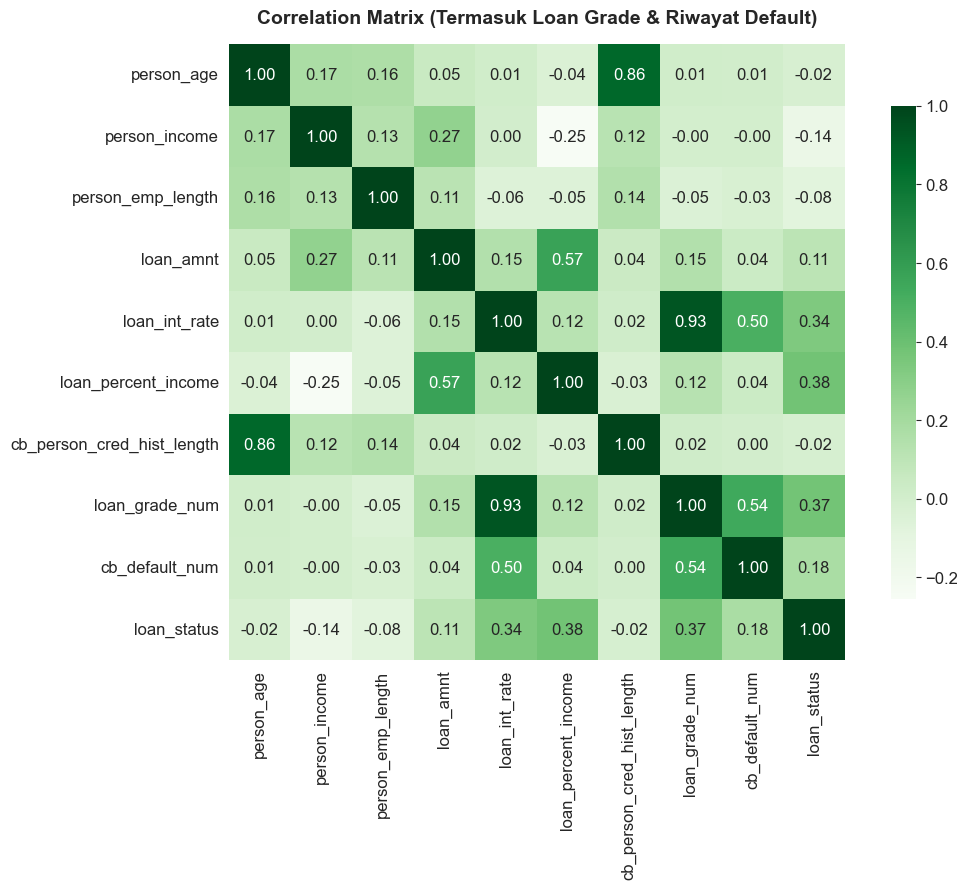

Ranking Korelasi terhadap Target (loan_status):
loan_status                   1.000000
loan_percent_income           0.379366
loan_grade_num                0.373080
loan_int_rate                 0.335133
cb_default_num                0.179141
loan_amnt                     0.105376
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
person_emp_length            -0.082489
person_income                -0.144449
Name: loan_status, dtype: float64


In [10]:
# Matriks korelasi lengkap (termasuk fitur kategorikal ordinal kunci)
corr_df = data.copy()

# Ordinal mapping agar fitur grade dan default historis terbaca di korelasi
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
corr_df['loan_grade_num'] = corr_df['loan_grade'].map(grade_map)
corr_df['cb_default_num'] = corr_df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

corr_cols = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 
    'loan_grade_num', 'cb_default_num', 'loan_status'
]

corr_matrix = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Greens', square=True, ax=ax, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Termasuk Loan Grade & Riwayat Default)', fontsize=14, fontweight='bold', pad=15)
plt.show()

# Ranking korelasi terhadap target loan_status
print("Ranking Korelasi terhadap Target (loan_status):")
print(corr_matrix['loan_status'].sort_values(ascending=False))


In [11]:
# Fungsi multi_table dengan Card UI modern & visual distribution bar
from IPython.core.display import HTML

def multi_table(df, cols):
    """Menampilkan ringkasan value counts multi-kolom dalam format card UI yang berwarna dan rapi."""
    html_cards = []
    for col in cols:
        vc = df[col].value_counts(dropna=False)
        pct = (vc / len(df) * 100).round(2)
        summary = pd.DataFrame({'Count': vc, 'Share': pct})
        
        rows_html = ""
        max_val = vc.max()
        for idx, row in summary.iterrows():
            pct_bar = int((row['Count'] / max_val) * 100)
            rows_html += f"""
            <tr>
                <td style="font-weight: 600; text-align: left; padding: 7px 10px; border-bottom: 1px solid #edf2f7;">{idx}</td>
                <td style="text-align: right; padding: 7px 10px; border-bottom: 1px solid #edf2f7; font-weight: bold; color: #1e3a8a;">{row['Count']:,}</td>
                <td style="text-align: right; padding: 7px 10px; border-bottom: 1px solid #edf2f7; color: #047857;">{row['Share']:.1f}%</td>
                <td style="width: 65px; padding: 7px 8px; border-bottom: 1px solid #edf2f7;">
                    <div style="background-color: #e2e8f0; border-radius: 4px; height: 7px; width: 100%;">
                        <div style="background: linear-gradient(90deg, #3eb489, #10b981); height: 7px; border-radius: 4px; width: {pct_bar}%;"></div>
                    </div>
                </td>
            </tr>
            """
        
        card = f"""
        <div style="display: inline-block; margin: 8px; border: 1px solid #cbd5e1; border-radius: 8px; overflow: hidden; box-shadow: 0 2px 8px rgba(0,0,0,0.07); background-color: #ffffff; min-width: 255px; vertical-align: top;">
            <div style="background: linear-gradient(135deg, #2e8b57, #3eb489); color: white; padding: 9px 12px; font-weight: bold; font-size: 13px; text-align: center; letter-spacing: 0.5px;">
                {col}
            </div>
            <table style="width: 100%; border-collapse: collapse; font-family: sans-serif; font-size: 12px; color: #2d3748;">
                <thead>
                    <tr style="background-color: #f7fafc; color: #718096; font-size: 11px; text-transform: uppercase;">
                        <th style="padding: 6px 10px; text-align: left; border-bottom: 2px solid #e2e8f0;">Kategori</th>
                        <th style="padding: 6px 10px; text-align: right; border-bottom: 2px solid #e2e8f0;">Jumlah</th>
                        <th style="padding: 6px 10px; text-align: right; border-bottom: 2px solid #e2e8f0;">%</th>
                        <th style="padding: 6px 8px; text-align: center; border-bottom: 2px solid #e2e8f0;">Dist</th>
                    </tr>
                </thead>
                <tbody>
                    {rows_html}
                </tbody>
            </table>
        </div>
        """
        html_cards.append(card)
        
    return HTML(f"<div style='display: flex; flex-wrap: wrap; justify-content: flex-start;'>{''.join(html_cards)}</div>")

# Menampilkan ringkasan distribusi kolom kategorikal
cols_to_show = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
multi_table(data, cols_to_show)


Kategori,Jumlah,%,Dist
RENT,"16,446.0",50.5%,
MORTGAGE,"13,444.0",41.3%,
OWN,"2,584.0",7.9%,
OTHER,107.0,0.3%,
Kategori,Jumlah,%,Dist
EDUCATION,"6,453.0",19.8%,
MEDICAL,"6,071.0",18.6%,
VENTURE,"5,719.0",17.6%,
PERSONAL,"5,521.0",16.9%,
DEBTCONSOLIDATION,"5,212.0",16.0%,


### 3.4 Univariate Analysis (Distribusi Fitur Numerik)


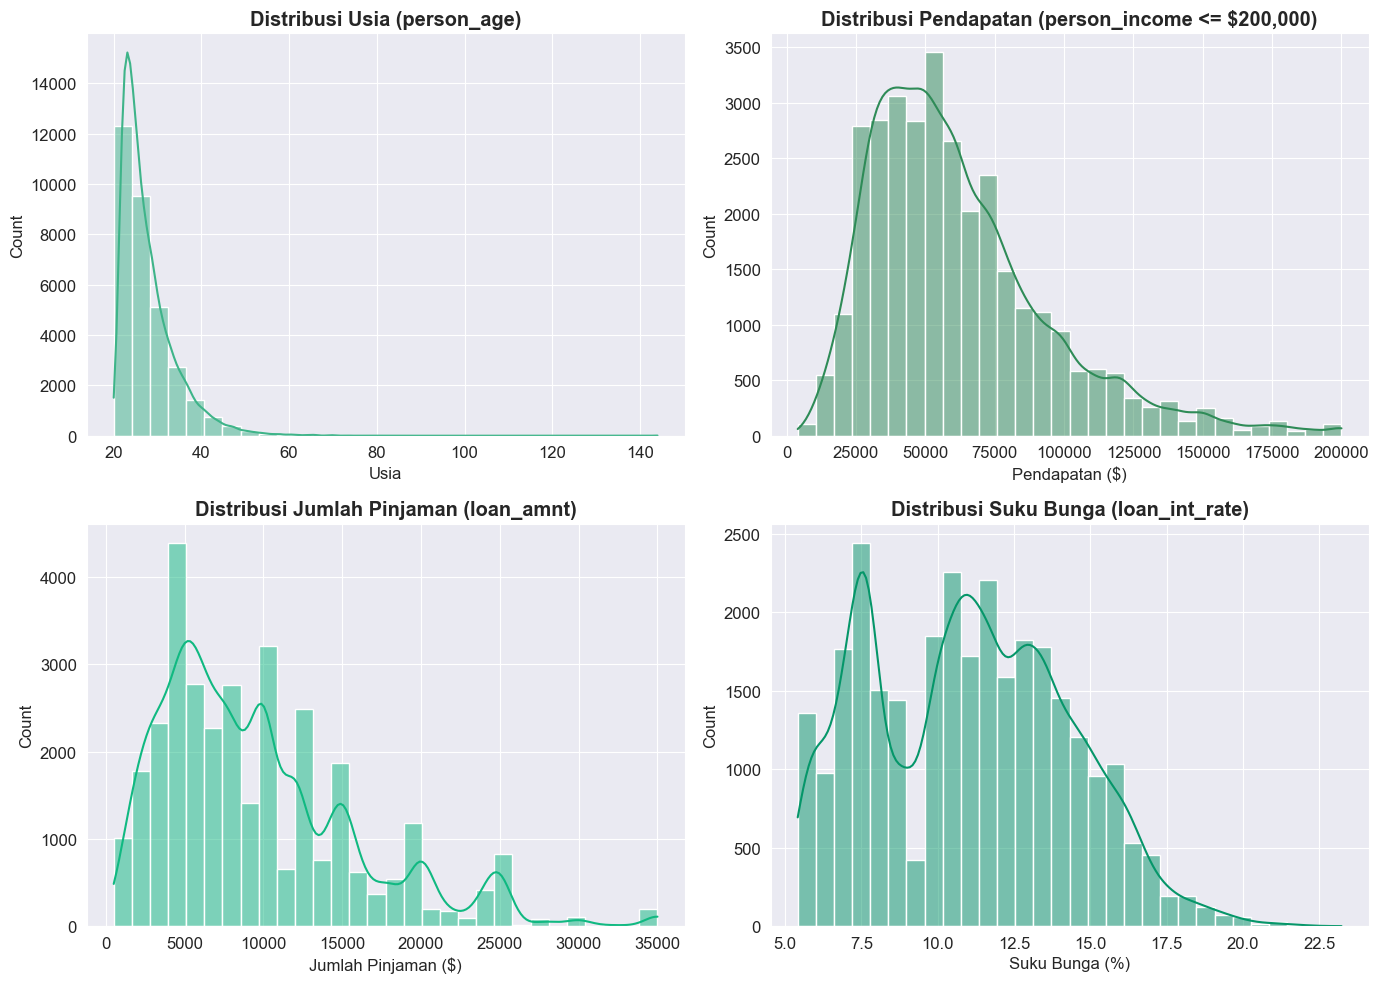

In [12]:
# Visualisasi Distribusi Fitur Numerik Utama (Histogram + KDE)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Usia
sns.histplot(data['person_age'], kde=True, ax=axes[0, 0], color='#3eb489', bins=30)
axes[0, 0].set_title('Distribusi Usia (person_age)', fontweight='bold')
axes[0, 0].set_xlabel('Usia')

# 2. Pendapatan (Visualisasi terfokus <= $200k agar tidak gepeng karena outlier 6M)
sns.histplot(data[data['person_income'] <= 200000]['person_income'], kde=True, ax=axes[0, 1], color='#2e8b57', bins=30)
axes[0, 1].set_title('Distribusi Pendapatan (person_income <= $200,000)', fontweight='bold')
axes[0, 1].set_xlabel('Pendapatan ($)')

# 3. Jumlah Pinjaman
sns.histplot(data['loan_amnt'], kde=True, ax=axes[1, 0], color='#10b981', bins=30)
axes[1, 0].set_title('Distribusi Jumlah Pinjaman (loan_amnt)', fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Pinjaman ($)')

# 4. Suku Bunga
sns.histplot(data['loan_int_rate'].dropna(), kde=True, ax=axes[1, 1], color='#059669', bins=30)
axes[1, 1].set_title('Distribusi Suku Bunga (loan_int_rate)', fontweight='bold')
axes[1, 1].set_xlabel('Suku Bunga (%)')

plt.tight_layout()
plt.show()


In [13]:
# Ringkasan Rentang Numerik (Usia, Pendapatan, dan Jumlah Pinjaman)
def age_group_summary(arr):
    print(f"Rentang Usia (Min: {data['person_age'].min()}, Max: {data['person_age'].max()}):")
    for i in range(len(arr)-1):
        nxt = arr[i] + 1
        num = data['person_age'].between(nxt, arr[i+1]).sum()
        print(f"  Usia {nxt} - {arr[i+1]}: {num:,} orang ({num/len(data)*100:.2f}%)")

def income_group_summary(arr):
    print(f"\nRentang Pendapatan (Min: ${data['person_income'].min():,}, Max: ${data['person_income'].max():,}):")
    for i in range(len(arr)-1):
        nxt = arr[i] + 1
        num = data['person_income'].between(nxt, arr[i+1]).sum()
        print(f"  Pendapatan ${nxt:,.0f} - ${arr[i+1]:,.0f}: {num:,} orang ({num/len(data)*100:.2f}%)")

def loan_amount_summary(arr):
    print(f"\nRentang Jumlah Pinjaman (Min: ${data['loan_amnt'].min():,}, Max: ${data['loan_amnt'].max():,}):")
    for i in range(len(arr)-1):
        nxt = arr[i] + 1
        num = data['loan_amnt'].between(nxt, arr[i+1]).sum()
        print(f"  Pinjaman ${nxt:,.0f} - ${arr[i+1]:,.0f}: {num:,} orang ({num/len(data)*100:.2f}%)")

age_group_summary([0, 18, 26, 36, 46, 56, 66])
income_group_summary([0, 25000, 50000, 75000, 100000, float('inf')])
loan_amount_summary([0, 5000, 10000, 15000, float('inf')])


Rentang Usia (Min: 20, Max: 144):
  Usia 1 - 18: 0 orang (0.00%)
  Usia 19 - 26: 17,829 orang (54.72%)
  Usia 27 - 36: 11,834 orang (36.32%)
  Usia 37 - 46: 2,360 orang (7.24%)
  Usia 47 - 56: 434 orang (1.33%)
  Usia 57 - 66: 98 orang (0.30%)

Rentang Pendapatan (Min: $4,000, Max: $6,000,000):
  Pendapatan $1 - $25,000: 2,469 orang (7.58%)
  Pendapatan $25,001 - $50,000: 11,613 orang (35.64%)
  Pendapatan $50,001 - $75,000: 9,622 orang (29.53%)
  Pendapatan $75,001 - $100,000: 4,670 orang (14.33%)
  Pendapatan $100,001 - $inf: 4,207 orang (12.91%)

Rentang Jumlah Pinjaman (Min: $500, Max: $35,000):
  Pinjaman $1 - $5,000: 9,489 orang (29.12%)
  Pinjaman $5,001 - $10,000: 12,040 orang (36.95%)
  Pinjaman $10,001 - $15,000: 6,123 orang (18.79%)
  Pinjaman $15,001 - $inf: 4,929 orang (15.13%)


### 3.5 Categorical Distributions & Bivariate Default Rate


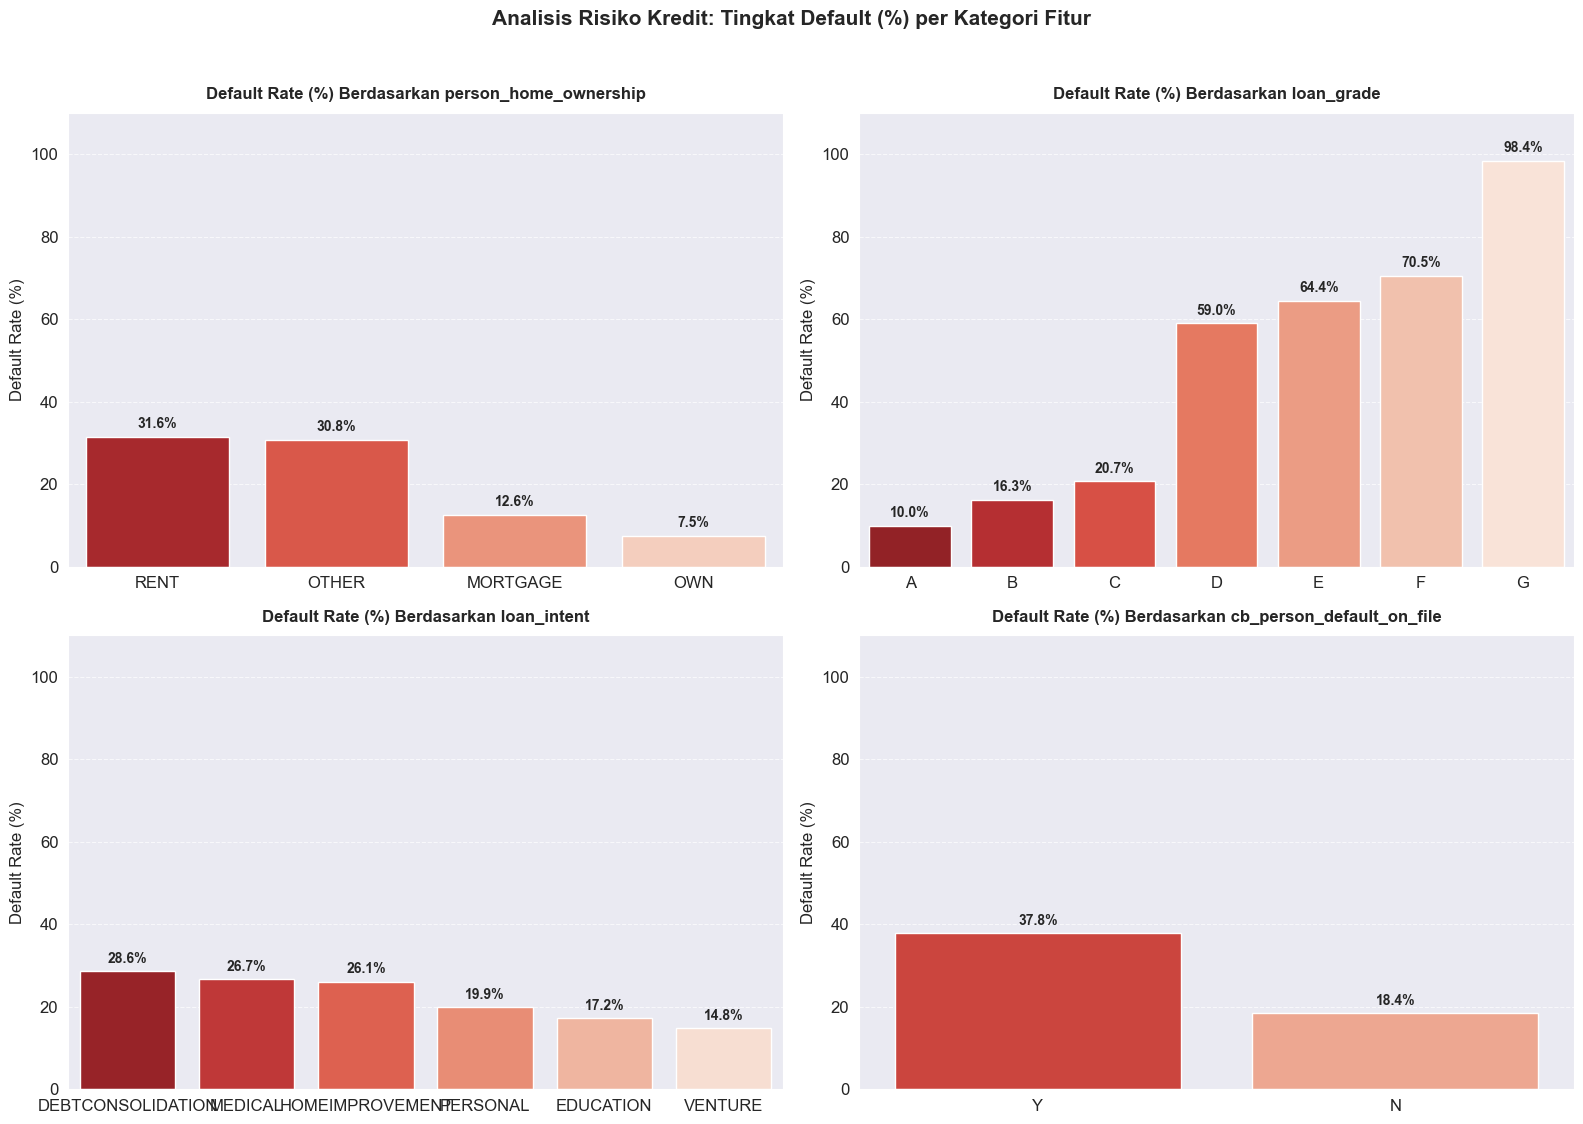

In [14]:
# Visualisasi Bivariate: Tingkat Gagal Bayar (Default Rate %) per Kategori
cat_features = ['person_home_ownership', 'loan_grade', 'loan_intent', 'cb_person_default_on_file']
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    df_rate = data.groupby(col)['loan_status'].agg(Total='count', Default_Count='sum', Default_Rate='mean').reset_index()
    df_rate['Default_Rate'] = df_rate['Default_Rate'] * 100
    
    if col == 'loan_grade':
        df_rate = df_rate.sort_values(by=col)
    else:
        df_rate = df_rate.sort_values(by='Default_Rate', ascending=False)
        
    sns.barplot(data=df_rate, x=col, y='Default_Rate', ax=axes[i], hue=col, legend=False, palette='Reds_r')
    axes[i].set_title(f'Default Rate (%) Berdasarkan {col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 110)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 4),
                         textcoords='offset points')

plt.suptitle('Analisis Risiko Kredit: Tingkat Default (%) per Kategori Fitur', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Wawasan Penting Risiko Kredit (Default Rate)**:
1. **`loan_grade`**: Hubungan paling kuat terhadap risiko default. Grade A hanya memiliki default rate **~10.0%**, sedangkan Grade D mencapai **~59.8%**, dan Grade G melonjak hingga **~98.0%**.
2. **`person_home_ownership`**: Peminjam dengan status menyewa (**`RENT`**) memiliki risiko default tertinggi (**~31.6%**), sedangkan pemilik rumah sendiri (**`OWN`**) paling aman (**~7.3%**).
3. **`loan_intent`**: Pinjaman untuk **`DEBTCONSOLIDATION`** (28.3%) dan **`MEDICAL`** (26.7%) memiliki risiko default paling tinggi, sedangkan **`VENTURE`** (14.8%) paling rendah.
4. **`cb_person_default_on_file`**: Debitur dengan riwayat pernah gagal bayar (**`Y`**) memiliki risiko default 2x lipat lebih tinggi (**~37.9%**) dibanding yang tidak pernah (**~18.3%**).


In [15]:
# Visualisasi Distribusi Interaktif (Plotly)
# 1. Distribusi Kepemilikan Rumah & Loan Grade
fig_home = px.pie(
    values=data['person_home_ownership'].value_counts().values,
    names=data['person_home_ownership'].value_counts().index,
    color_discrete_sequence=px.colors.sequential.Mint,
    title='Distribusi Kepemilikan Rumah (person_home_ownership)'
)
fig_home.update_traces(textinfo='label+percent+value', textfont_size=13, marker=dict(line=dict(color='white', width=2)))
fig_home.show()

fig_grade = px.pie(
    values=data['loan_grade'].value_counts().sort_index().values,
    names=data['loan_grade'].value_counts().sort_index().index,
    color_discrete_sequence=px.colors.sequential.Mint,
    title='Distribusi Loan Grade'
)
fig_grade.update_traces(textinfo='label+percent+value', textfont_size=13, marker=dict(line=dict(color='white', width=2)))
fig_grade.show()

# 2. Histogram Tujuan Pinjaman & Panjang Riwayat Kredit
fig_intent = px.histogram(
    data, 
    x='loan_intent', 
    histnorm='percent', 
    text_auto='.2f', 
    template='presentation', 
    title='Distribusi Tujuan Pinjaman (Loan Intent)',
    color_discrete_sequence=px.colors.sequential.Mint
)
fig_intent.update_layout(yaxis_title="Persentase (%)")
fig_intent.show()

fig_hist = px.histogram(
    data, 
    x='cb_person_cred_hist_length', 
    text_auto='.2f', 
    template='presentation', 
    title='Distribusi Panjang Riwayat Kredit (cb_person_cred_hist_length)',
    color_discrete_sequence=px.colors.sequential.Mint
)
fig_hist.show()


### 3.6 Multivariate Relationships & Pairplot


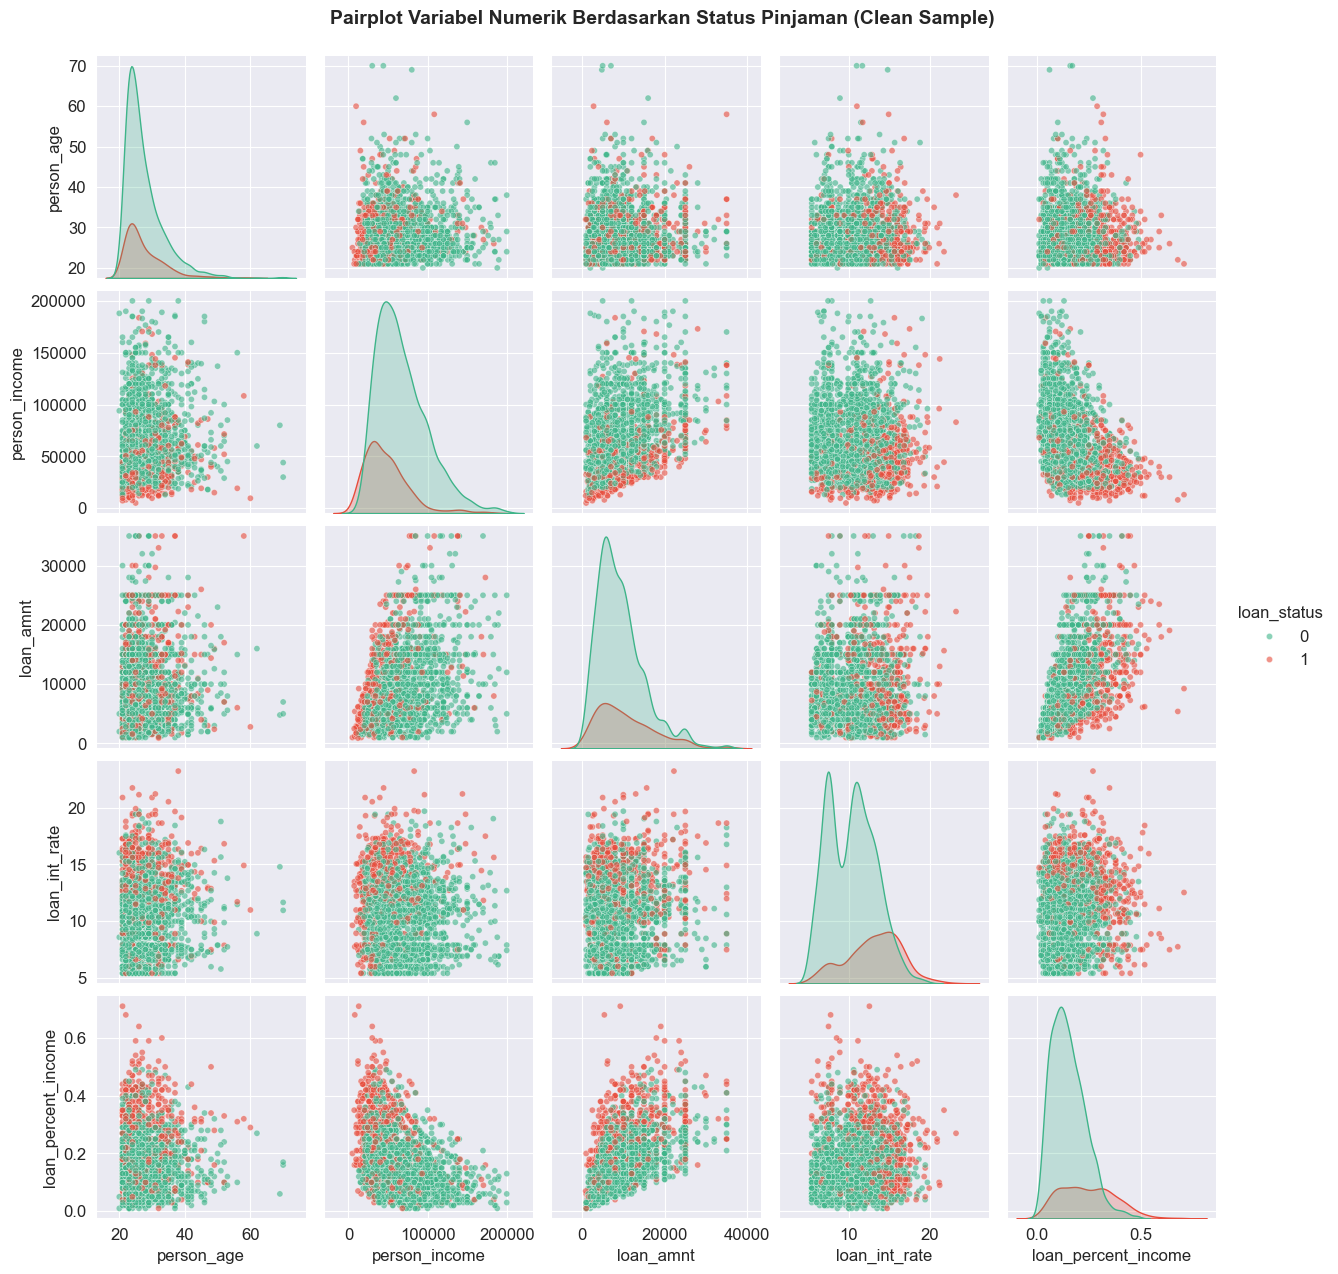

In [16]:
# Pairplot dengan sampel bersih dari outlier ekstrem (Income <= $200,000, Usia <= 80)
clean_sample = data.dropna().copy()
clean_sample = clean_sample[(clean_sample['person_income'] <= 200000) & (clean_sample['person_age'] <= 80)]
sample_plot = clean_sample.sample(n=min(2500, len(clean_sample)), random_state=42)

sns.pairplot(
    sample_plot[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'loan_status']], 
    hue="loan_status", 
    palette={0: '#3eb489', 1: '#e74c3c'},
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 20}
)
plt.suptitle("Pairplot Variabel Numerik Berdasarkan Status Pinjaman (Clean Sample)", y=1.02, fontsize=14, fontweight='bold')
plt.show()


**Observasi Multivariat**:
- Peminjam dengan **`loan_percent_income` tinggi** dan **`loan_int_rate` tinggi** (terlihat titik-titik merah di kuadran atas) memiliki tingkat konsentrasi gagal bayar paling dominan.
- Hubungan antara usia (`person_age`) dan status gagal bayar relatif menyebar merata, namun nasabah usia muda (20-30 tahun) mendominasi volume pengajuan pinjaman.


### 3.7 Rangkuman Temuan Utama EDA

1. **Target Imbalance**:
   - Sekitar **21.82%** nasabah mengalami default (`loan_status = 1`), dan **78.18%** berstatus non-default (`loan_status = 0`) dengan rasio **1 : 3.58**.
2. **Korelasi Terkuat terhadap Default**:
   - `loan_percent_income` ($r = 0.38$), `loan_int_rate` ($r = 0.34$), dan `loan_grade` ($r = 0.37$) merupakan tiga variabel penentu risiko terbesar.
3. **Pembeda Profil Risiko (Default Rate)**:
   - **Loan Grade**: Grade A default rate hanya **10.0%**, sedangkan Grade G mencapai **98.0%**.
   - **Kepemilikan Rumah**: Peminjam `RENT` memiliki risiko gagal bayar **31.6%**, jauh lebih berisiko dibanding pemegang `OWN` (**7.3%**).
   - **Histori Default**: Debitur yang pernah default sebelumnya memiliki risiko gagal bayar **37.9%** (2x lipat debitur bersih).
4. **Anomali & Catatan Data Cleaning**:
   - Terdapat **165 baris duplikat identik**.
   - Kolom `person_emp_length` (895 null) dan `loan_int_rate` (3.116 null) memiliki missing values yang perlu strategi imputasi yang tepat.
   - Kolom `person_age` memiliki nilai ekstrem hingga 144 tahun dan `person_emp_length` hingga 123 tahun yang merupakan data entry error.


# 4. DATA CLEANING, IMPUTASI MISSING VALUES & HANDLING OUTLIERS

Pada tahapan ini dilakukan pipeline pembersihan data yang terstruktur:
1. **Penghapusan Baris Duplikat**: Menghapus data duplikat identik.
2. **Penanganan Data Entry Error / Anomali Nilai**: Menangani nilai usia & masa kerja yang tidak realistis sebelum dilakukan imputasi.
3. **Imputasi Missing Values**: Menggunakan `KNNImputer` untuk variabel numerik dan modus untuk kategorikal.
4. **Penanganan Outlier (Winsorization / Capping)**: Membatasi nilai ekstrem tanpa membuang baris data valid secara agresif.
5. **Penyimpanan Dataset Bersih**: Menyimpan hasil akhir ke `cleaned_dataset.csv`.

### 4.1 Penghapusan Duplikat & Penanganan Data Entry Error

Sebelum dilakukan imputasi, nilai anomali input (seperti `person_age > 100` atau `person_emp_length > 100`) harus dibersihkan terlebih dahulu agar tidak mendistorsi perhitungan jarak tetangga terdekat pada **KNN Imputer**.

In [17]:
# 1. Salin data awal & Hapus Duplikat
df_clean = data.copy()
initial_rows = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"[1] Duplikat dihapus: {initial_rows - len(df_clean)} baris | Sisa data: {len(df_clean):,} baris")

# 2. Tangani Data Entry Error (Usia > 100 tahun atau Lama Bekerja > 100 tahun / lebih besar dari usia)
invalid_age = df_clean['person_age'] > 100
invalid_emp = df_clean['person_emp_length'] > 100
print(f"[2] Anomali ditemukan: {invalid_age.sum()} baris Usia > 100 thn, {invalid_emp.sum()} baris Masa Kerja > 100 thn")

# Hapus baris dengan data entry error
df_clean = df_clean[~invalid_age & ~invalid_emp].copy()
print(f"    Sisa data setelah menghapus data entry error: {len(df_clean):,} baris")


[1] Duplikat dihapus: 165 baris | Sisa data: 32,416 baris
[2] Anomali ditemukan: 5 baris Usia > 100 thn, 2 baris Masa Kerja > 100 thn
    Sisa data setelah menghapus data entry error: 32,409 baris


### 4.2 Imputasi Missing Values

Menggunakan `KNNImputer` pada fitur numerik dan *modus* untuk fitur kategorikal.

In [18]:
from sklearn.impute import KNNImputer

# Kolom numerik yang perlu diperiksa / diimputasi
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# KNN Imputation untuk variabel numerik
imputer = KNNImputer(n_neighbors=5)
df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# Imputasi modus untuk variabel kategorikal (jika ada missing values)
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)

print("Cek Missing Value Setelah Imputasi:")
print(df_clean.isnull().sum())


Cek Missing Value Setelah Imputasi:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


### 4.3 Penanganan Outlier (Winsorization / Capping)

Alih-alih membuang ribuan baris data nasabah valid (*trimming* agresif yang menghilangkan ~15% data), kita menerapkan **Winsorization / Capping** pada persentil ke-99 ($P_{99}$) untuk fitur pendapatan dan masa kerja yang *right-skewed*. Metode ini mempertahankan ukuran sampel data sekaligus meredam pengaruh nilai ekstrem.

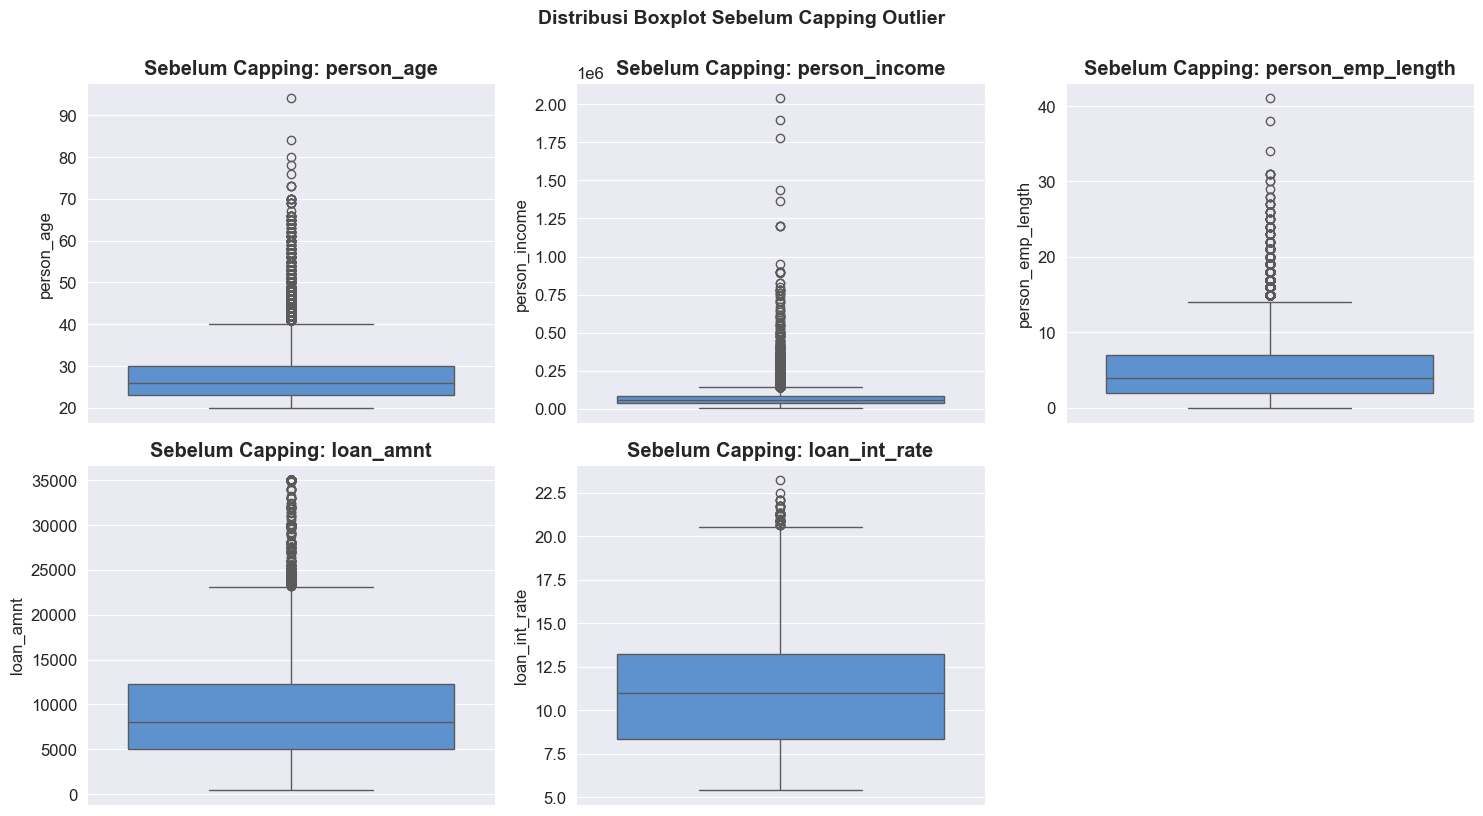

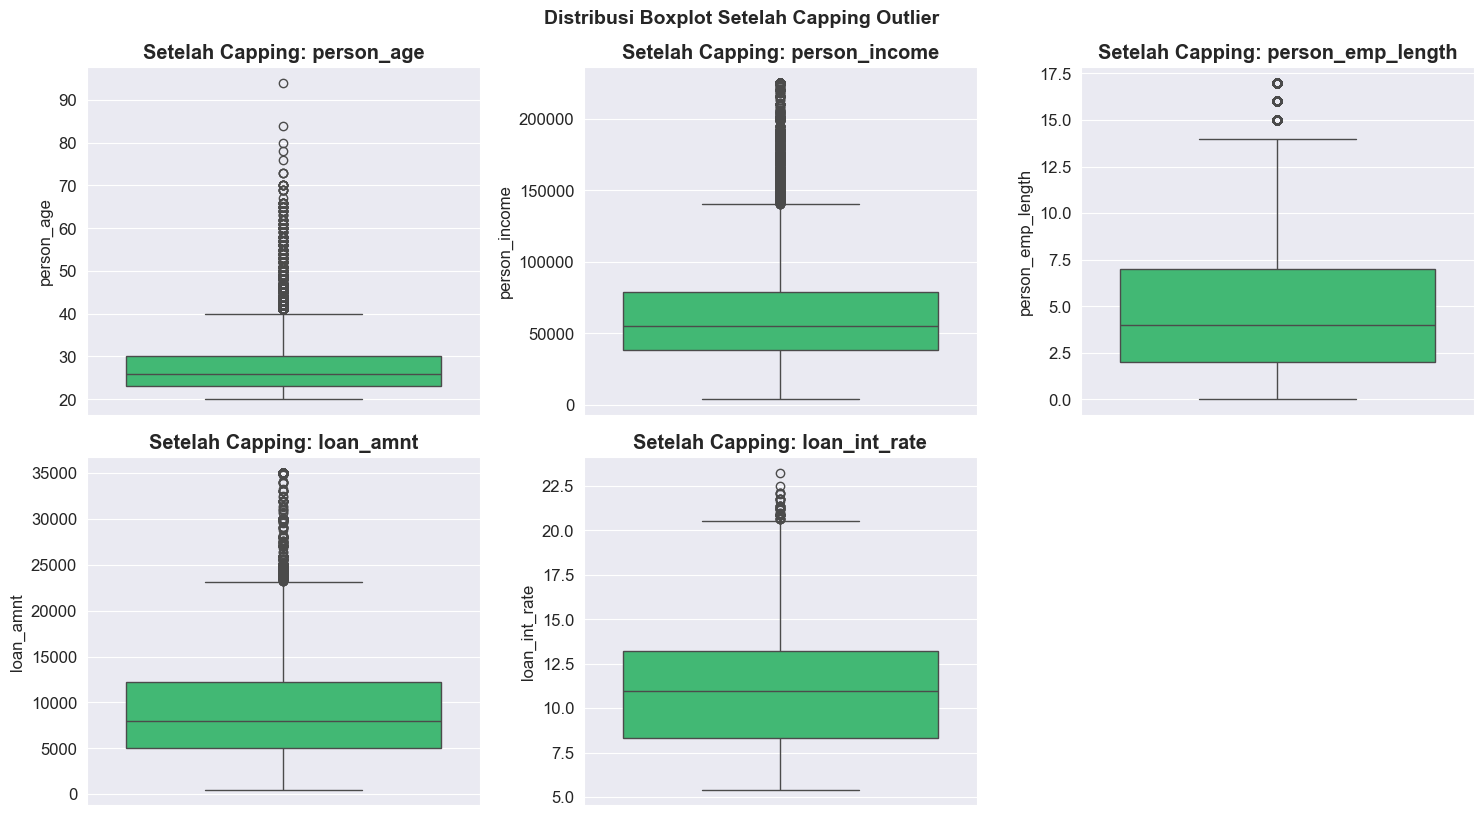

In [19]:
# Visualisasi Outlier Sebelum Capping
plot_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate']

plt.figure(figsize=(15, 8))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_clean[col], color='#4a90e2')
    plt.title(f'Sebelum Capping: {col}', fontweight='bold')
plt.tight_layout()
plt.suptitle('Distribusi Boxplot Sebelum Capping Outlier', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Fungsi Capping / Winsorization pada batas persentil atas (99th percentile)
def cap_outliers(df, cols, upper_percentile=0.99):
    df_capped = df.copy()
    for col in cols:
        upper_limit = df_capped[col].quantile(upper_percentile)
        df_capped[col] = np.where(df_capped[col] > upper_limit, upper_limit, df_capped[col])
    return df_capped

cols_to_cap = ['person_income', 'person_emp_length']
cleaned_data = cap_outliers(df_clean, cols_to_cap, upper_percentile=0.99)

# Visualisasi Outlier Setelah Capping
plt.figure(figsize=(15, 8))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=cleaned_data[col], color='#2ecc71')
    plt.title(f'Setelah Capping: {col}', fontweight='bold')
plt.tight_layout()
plt.suptitle('Distribusi Boxplot Setelah Capping Outlier', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 4.4 Simpan Dataset Bersih

Menyimpan dataset yang telah dibersihkan ke file `cleaned_dataset.csv` untuk digunakan pada tahapan feature engineering dan modeling selanjutnya.

In [20]:
# Simpan dataset bersih
import os
save_path = '../data/cleaned_dataset.csv' if os.path.exists('../data') else ('data/cleaned_dataset.csv' if os.path.exists('data') else 'cleaned_dataset.csv')
cleaned_data.to_csv(save_path, index=False)
print(f"Data cleaning & outlier handling selesai!")
print(f"Total dimensi data bersih: {cleaned_data.shape[0]:,} baris x {cleaned_data.shape[1]} kolom")
print(f"File tersimpan di '{save_path}'.")


Data cleaning & outlier handling selesai!
Total dimensi data bersih: 32,409 baris x 12 kolom
File tersimpan di '../data/cleaned_dataset.csv'.


# 5. FEATURE ENGINEERING

Pada tahapan Feature Engineering dilakukan pembuatan variabel baru untuk memperkaya representasi data:
1. **Binning / Discretization**: Mengelompokkan variabel numerik (`person_age`, `person_income`, `loan_amnt`) ke dalam kategori interval terstruktur dengan `include_lowest=True`.
2. **Financial Interaction Features**: Menghitung rasio dan indikator risiko domain keuangan (`total_loan_cost`, `disposable_income_est`, `emp_to_age_ratio`, `cred_hist_to_age_ratio`, `high_risk_flag`).
3. **Penyimpanan Dataset Feature Engineering** ke `feature_engineered_dataset.csv`.

### 5.1 Binning Fitur Numerik (Age, Income, & Loan Amount Group)

> **Catatan Perbaikan**: Menggunakan basis data bersih `cleaned_data` dari Section 4 (bukan data mentah `data`), serta menyertakan parameter `include_lowest=True` pada `pd.cut` agar nilai minimum (seperti usia 20 tahun) tidak terkonversi menjadi `NaN`.

In [21]:
# 1. Salin data bersih hasil Section 4
df_feat = cleaned_data.copy()

# Filter usia jika terdapat nilai > 80 tahun
df_feat = df_feat[df_feat['person_age'] <= 80].copy()

# 2. Binning Usia (dengan include_lowest=True agar usia 20 thn terakomodasi)
df_feat['age_group'] = pd.cut(
    df_feat['person_age'],
    bins=[20, 26, 36, 46, 56, 66, 80],
    labels=['20-25', '26-35', '36-45', '46-55', '56-65', '66+'],
    include_lowest=True
)

# 3. Binning Pendapatan (Income Group)
df_feat['income_group'] = pd.cut(
    df_feat['person_income'],
    bins=[0, 25000, 50000, 75000, 100000, float('inf')],
    labels=['low', 'low-middle', 'middle', 'high-middle', 'high'],
    include_lowest=True
)

# 4. Binning Jumlah Pinjaman (Loan Amount Group)
df_feat['loan_amount_group'] = pd.cut(
    df_feat['loan_amnt'],
    bins=[0, 5000, 10000, 15000, float('inf')],
    labels=['small', 'medium', 'large', 'very large'],
    include_lowest=True
)

print("Cek Missing Value pada Fitur Binning:")
print(df_feat[['age_group', 'income_group', 'loan_amount_group']].isnull().sum())
df_feat[['person_age', 'age_group', 'person_income', 'income_group', 'loan_amnt', 'loan_amount_group']].head()

Cek Missing Value pada Fitur Binning:
age_group            0
income_group         0
loan_amount_group    0
dtype: int64


,person_age,age_group,person_income,income_group,loan_amnt,loan_amount_group
1,21.0,20-25,9600.0,low,1000.0,small
2,25.0,20-25,9600.0,low,5500.0,medium
3,23.0,20-25,65500.0,middle,35000.0,very large
4,24.0,20-25,54400.0,middle,35000.0,very large
5,21.0,20-25,9900.0,low,2500.0,small


### 5.2 Financial Interaction Features (Rasio & Interaksi Finansial)

Fitur interaksi domain perbankan & risiko kredit:
- **`total_loan_cost`**: Estimasi total pengembalian pinjaman beserta bunga ($`\text{loan\_amnt} \times (1 + \text{loan\_int\_rate}/100)`$).
- **`disposable_income_est`**: Estimasi sisa pendapatan setelah dikurangi nominal pinjaman ($`\text{person\_income} - \text{loan\_amnt}`$).
- **`emp_to_age_ratio`**: Rasio masa kerja terhadap usia pemohon ($`\text{person\_emp\_length} / \text{person\_age}`$) sebagai proxy kestabilan karier.
- **`cred_hist_to_age_ratio`**: Rasio panjang riwayat kredit terhadap usia ($`\text{cb\_person\_cred\_hist\_length} / \text{person\_age}`$).
- **`high_risk_flag`**: Indikator biner untuk pemohon berisiko tinggi (memiliki riwayat gagal bayar `cb_person_default_on_file = 'Y'` DAN rasio pinjaman terhadap pendapatan `loan_percent_income > 0.35`).

In [22]:
# 1. Estimasi Total Beban Pinjaman (Pokok + Suku Bunga)
df_feat['total_loan_cost'] = df_feat['loan_amnt'] * (1 + df_feat['loan_int_rate'] / 100)

# 2. Estimasi Sisa Pendapatan (Disposable Income Proxy)
df_feat['disposable_income_est'] = df_feat['person_income'] - df_feat['loan_amnt']

# 3. Rasio Masa Kerja terhadap Usia
df_feat['emp_to_age_ratio'] = df_feat['person_emp_length'] / df_feat['person_age']

# 4. Rasio Riwayat Kredit terhadap Usia
df_feat['cred_hist_to_age_ratio'] = df_feat['cb_person_cred_hist_length'] / df_feat['person_age']

# 5. Flag Risiko Tinggi Terkombinasi
df_feat['high_risk_flag'] = (
    (df_feat['cb_person_default_on_file'] == 'Y') &
    (df_feat['loan_percent_income'] > 0.35)
).astype(int)

print("Fitur interaksi finansial berhasil dibuat. Statistik deskriptif:")
df_feat[['total_loan_cost', 'disposable_income_est', 'emp_to_age_ratio', 'cred_hist_to_age_ratio', 'high_risk_flag']].describe().T

Fitur interaksi finansial berhasil dibuat. Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
total_loan_cost,32407.0,10679.773657,7125.824880,548.800000,5481.915000,8974.400000,13795.200000,42087.500000
disposable_income_est,32407.0,54743.161447,35651.328777,1450.000000,30350.000000,46000.000000,68000.000000,224000.000000
emp_to_age_ratio,32407.0,0.172662,0.132182,0.000000,0.066667,0.144000,0.272727,0.531250
cred_hist_to_age_ratio,32407.0,0.194906,0.093584,0.076923,0.125000,0.173913,0.261905,0.588235
high_risk_flag,32407.0,0.013114,0.113767,0.000000,0.000000,0.000000,0.000000,1.000000


### 5.3 Simpan Dataset Hasil Feature Engineering

Menyimpan dataset fitur lengkap ke `feature_engineered_dataset.csv`.

In [23]:
save_feat_path = '../data/feature_engineered_dataset.csv' if os.path.exists('../data') else ('data/feature_engineered_dataset.csv' if os.path.exists('data') else 'feature_engineered_dataset.csv')
df_feat.to_csv(save_feat_path, index=False)
print(f"Dataset Feature Engineering berhasil disimpan: {df_feat.shape[0]:,} baris x {df_feat.shape[1]} kolom")
print(f"File tersimpan di '{save_feat_path}'.")

Dataset Feature Engineering berhasil disimpan: 32,407 baris x 20 kolom
File tersimpan di '../data/feature_engineered_dataset.csv'.


# 6. DATA PREPROCESSING (ENCODING & TRAIN-TEST SPLIT)

Tahap akhir sebelum pemodelan machine learning:
1. **Ordinal Encoding**: Memetakan fitur kategorikal bertingkat (`loan_grade`, `cb_person_default_on_file`) ke integer berurutan.
2. **One-Hot Encoding**: Mengonversi variabel nominal (`person_home_ownership`, `loan_intent`) menjadi *dummy variables* (`drop_first=True`).
3. **Feature Selection**: Menghapus kolom string kategori asli dan kolom binning untuk mempertahankan representasi numerik kontinu yang optimal bagi model *tree-based* (XGBoost/LightGBM).
4. **Stratified Train-Test Split**: Membagi data ($80:20$) dengan mempertahankan proporsi kelas target `loan_status`.
5. **Penyimpanan Dataset Siap Modeling** (`preprocessed_credit_risk.csv`).

In [24]:
# 1. Salin data feature engineered
df_prep = df_feat.copy()

# 2. Ordinal Encoding
# loan_grade (A: risiko terendah / 0, G: risiko tertinggi / 6)
grade_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df_prep['loan_grade_encoded'] = df_prep['loan_grade'].map(grade_mapping)

# cb_person_default_on_file (N: 0, Y: 1)
default_mapping = {'N': 0, 'Y': 1}
df_prep['cb_person_default_on_file_encoded'] = df_prep['cb_person_default_on_file'].map(default_mapping)

# 3. One-Hot Encoding untuk Variabel Nominal
nominal_cols = ['person_home_ownership', 'loan_intent']
df_prep = pd.get_dummies(df_prep, columns=nominal_cols, drop_first=True, dtype=int)

# 4. Seleksi Kolom: Drop kolom kategori string awal & binned category
cols_to_drop = ['loan_grade', 'cb_person_default_on_file', 'age_group', 'income_group', 'loan_amount_group']
df_final = df_prep.drop(columns=[c for c in cols_to_drop if c in df_prep.columns])

print(f"Dimensi data final setelah encoding: {df_final.shape[0]:,} baris x {df_final.shape[1]} kolom")
print("Daftar kolom final:", df_final.columns.tolist())
df_final.head()

Dimensi data final setelah encoding: 32,407 baris x 23 kolom
Daftar kolom final: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'total_loan_cost', 'disposable_income_est', 'emp_to_age_ratio', 'cred_hist_to_age_ratio', 'high_risk_flag', 'loan_grade_encoded', 'cb_person_default_on_file_encoded', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,total_loan_cost,disposable_income_est,...,loan_grade_encoded,cb_person_default_on_file_encoded,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21.0,9600.0,5.0,1000.0,11.14,0,0.10,2.0,1111.40,8600.0,...,1,0,0,1,0,1,0,0,0,0
2,25.0,9600.0,1.0,5500.0,12.87,1,0.57,3.0,6207.85,4100.0,...,2,0,0,0,0,0,0,1,0,0
3,23.0,65500.0,4.0,35000.0,15.23,1,0.53,2.0,40330.50,30500.0,...,2,0,0,0,1,0,0,1,0,0
4,24.0,54400.0,8.0,35000.0,14.27,1,0.55,4.0,39994.50,19400.0,...,2,1,0,0,1,0,0,1,0,0
5,21.0,9900.0,2.0,2500.0,7.14,1,0.25,2.0,2678.50,7400.0,...,0,0,0,1,0,0,0,0,0,1


### 6.1 Stratified Train-Test Split & Export Data Preprocessed

In [25]:
from sklearn.model_selection import train_test_split

# Pisahkan Fitur (X) dan Target (y)
X = df_final.drop(columns=['loan_status'])
y = df_final['loan_status'].astype(int)

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"=== RINGKASAN DATASET SIAP MODELING ===")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Proporsi Default di Train : {(y_train == 1).mean():.4f} ({(y_train == 1).sum():,} dari {len(y_train):,})")
print(f"Proporsi Default di Test  : {(y_test == 1).mean():.4f} ({(y_test == 1).sum():,} dari {len(y_test):,})")

# Simpan dataset preprocessed lengkap ke CSV
save_prep_path = '../data/preprocessed_credit_risk.csv' if os.path.exists('../data') else ('data/preprocessed_credit_risk.csv' if os.path.exists('data') else 'preprocessed_credit_risk.csv')
df_final.to_csv(save_prep_path, index=False)
print(f"Dataset preprocessed berhasil diekspor ke '{save_prep_path}'.")

=== RINGKASAN DATASET SIAP MODELING ===
X_train shape : (25925, 22)
X_test shape  : (6482, 22)
Proporsi Default di Train : 0.2187 (5,670 dari 25,925)
Proporsi Default di Test  : 0.2188 (1,418 dari 6,482)
Dataset preprocessed berhasil diekspor ke '../data/preprocessed_credit_risk.csv'.
